# Análise Bioestatística da Retinopatia Diabética

## Atividade Prática 01 de Projeto em Computação

### Objetivo

Realizar a análise bioestatística do **mBRSET - Mobile Brazilian Retinal Dataset**, selecionado no notebook `00_dataset_comparison.ipynb`.

O notebook foi organizado para responder diretamente aos requisitos da atividade:

- descrever a origem e a estrutura do dataset;
- documentar limpeza, tipos, representação das variáveis categóricas, duplicidades, valores ausentes e inconsistências;
- apresentar estatísticas descritivas e frequências absolutas e relativas;
- caracterizar a amostra por idade, sexo e estágio da Retinopatia Diabética;
- apresentar pelo menos três tipos de gráficos, com títulos, eixos e interpretação;
- analisar a correlação entre duas variáveis numéricas;
- comparar uma variável clínica entre dois ou mais grupos;
- apresentar H0, H1, α, valor-p e conclusão dos testes;
- discutir a magnitude dos resultados, suas limitações e o contexto clínico.

As análises inferenciais são feitas em nível de paciente para que imagens repetidas do mesmo indivíduo não sejam tratadas como observações independentes. As conclusões se restringem ao conjunto analisado.

# 1. Dataset selecionado

O dataset reúne imagens de fundo de olho obtidas com câmera portátil e metadados clínicos e demográficos de pessoas com diabetes.

A versão 1.0 do PhysioNet documenta:

- 5.164 imagens de 1.291 pacientes;
- idade, sexo e escolaridade;
- duração da diabetes;
- uso e duração da insulinoterapia;
- tratamento oral;
- hipertensão arterial sistêmica;
- consumo de álcool, tabagismo e obesidade;
- doença vascular, infarto agudo do miocárdio, nefropatia, neuropatia e pé diabético;
- classificação da Retinopatia Diabética pela escala ICDR (0 - 4);
- edema macular.

As imagens foram avaliadas por especialistas em retina, com adjudicação em caso de discordância. A documentação do mBRSET informa *weighted kappa* de 0,863 para a classificação ICDR.

### Fontes

- PhysioNet: https://physionet.org/content/mbrset/1.0/
- Repositório dos autores: https://github.com/luisnakayama/mBRSET
- Wu, C., Restrepo, D., Nakayama, L.F. et al. A portable retina fundus photos dataset for clinical, demographic, and diabetic retinopathy prediction. Sci Data 12, 323 (2025). https://doi.org/10.1038/s41597-025-04627-3

### Unidade de análise

O arquivo original possui várias imagens por paciente. Para evitar que o mesmo indivíduo seja contado mais de uma vez nas análises, os dados foram resumidos em uma tabela com uma linha por paciente.

Para os desfechos oftalmológicos:

- o `icdr_patient` representa o maior estágio de Retinopatia Diabética observado para cada paciente;
- o `edema_patient` indica se houve presença de edema em pelo menos uma das imagens.

Essas variáveis foram criadas apenas para organizar a análise em nível de paciente e não fazem parte dos rótulos originais do mBRSET.

## Contexto da seleção do dataset

Antes desta análise, o notebook `00_dataset_comparison.ipynb` realizou uma triagem estrutural e estatística de diferentes datasets públicos relacionados à Retinopatia Diabética.

Nessa etapa foram comparados aspectos como presença de variáveis clínicas e demográficas, disponibilidade de desfechos relacionados à RD, possibilidade de correlação entre variáveis numéricas, formação de grupos para comparação e unidade de análise.

O **mBRSET** foi selecionado porque atendeu bem aos requisitos definidos para a atividade e apresentou, entre os datasets elegíveis, maior disponibilidade de variáveis clínicas estruturadas e maior número de combinações possíveis para análise de correlação. Além disso, possui variáveis demográficas e classificação de gravidade da Retinopatia Diabética pela escala ICDR.

Por esse motivo, o mBRSET foi adotado como base da análise bioestatística desenvolvida neste notebook.

# 2. Bibliotecas e configuração

In [1]:
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from IPython.display import display
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns",100)
plt.rcParams["figure.dpi"] = 120

ALPHA = 0.05
RANDOM_STATE = 42

# 3. Carregamento dos dados

O arquivo tabular é carregado diretamente do [repositório público](https://github.com/luisnakayama/mBRSET/blob/main/dataframe_brsetmobile.csv) mantido pelos autores. As imagens não são necessárias para os objetivos estatísticos desta atividade.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/luisnakayama/mBRSET/main/dataframe_brsetmobile.csv"

df_raw = pd.read_csv(DATA_URL)

print(f"Dimensão original: {df_raw.shape[0]} linhas × {df_raw.shape[1]} colunas")
display(df_raw.head())

Dimensão original: 5164 linhas × 24 colunas


,patient,age,sex,dm_time,insulin,insulin_time,oraltreatment_dm,systemic_hypertension,insurance,educational_level,alcohol_consumption,smoking,obesity,vascular_disease,acute_myocardial_infarction,nephropathy,neuropathy,diabetic_foot,file,laterality,final_artifacts,final_quality,final_icdr,final_edema
0,1,58,1,15.0,1.0,NaN,1.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.1.jpg,right,yes,yes,4.0,no
1,1,58,1,15.0,1.0,NaN,1.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.2.jpg,right,yes,yes,4.0,no
2,1,58,1,15.0,1.0,NaN,1.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.3.jpg,left,yes,yes,4.0,no
3,1,58,1,15.0,1.0,NaN,1.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.4.jpg,left,yes,yes,4.0,no
4,10,63,0,7.0,0.0,NaN,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.1.jpg,right,yes,yes,0.0,no


# 4. Auditoria inicial do dataset

In [3]:
print("Colunas:")
print(df_raw.columns.tolist())

print("\nTipos originais:")
display(df_raw.dtypes.rename("dtype").to_frame())

n_patients_raw = int(df_raw["patient"].nunique(dropna=True))
print("\nDuplicatas exatas:",int(df_raw.duplicated().sum()))
print("Pacientes únicos:",n_patients_raw)
print("Registros por paciente:",round(len(df_raw) / n_patients_raw,2))

Colunas:
['patient', 'age', 'sex', 'dm_time', 'insulin', 'insulin_time', 'oraltreatment_dm', 'systemic_hypertension', 'insurance', 'educational_level', 'alcohol_consumption', 'smoking', 'obesity', 'vascular_disease', 'acute_myocardial_infarction', 'nephropathy', 'neuropathy', 'diabetic_foot', 'file', 'laterality', 'final_artifacts', 'final_quality', 'final_icdr', 'final_edema']

Tipos originais:


,dtype
patient,int64
age,int64
sex,int64
dm_time,float64
insulin,float64
insulin_time,float64
oraltreatment_dm,float64
systemic_hypertension,float64
insurance,float64
educational_level,float64



Duplicatas exatas: 0
Pacientes únicos: 1291
Registros por paciente: 4.0


In [4]:
missing_raw = pd.DataFrame(
    {"n_ausentes":df_raw.isna().sum(),
     "pct_ausentes":df_raw.isna().mean().mul(100)}
    ).sort_values(
        "pct_ausentes", ascending=False
        )

print("Valores ausentes no arquivo original:")
display(missing_raw[missing_raw["n_ausentes"] > 0].round(2))

Valores ausentes no arquivo original:


,n_ausentes,pct_ausentes
insulin_time,4148,80.33
final_icdr,280,5.42
final_edema,265,5.13
diabetic_foot,108,2.09
smoking,88,1.70
acute_myocardial_infarction,84,1.63
nephropathy,80,1.55
vascular_disease,76,1.47
obesity,76,1.47
neuropathy,76,1.47


A maior proporção de valores ausentes ocorre em insulin_time. Um detalhe importante é que ele deve ser interpretado com cuidado, pois a variável se aplica apenas aos pacientes que fazem uso de insulina. Por isso, sua ausência será analisada separadamente antes das análises estatísticas.

Os demais valores ausentes serão tratados de acordo com as variáveis envolvidas em cada análise, sem imputação automática.

## 4.1 Unidade observacional

O número de linhas não corresponde ao número de indivíduos. Cada linha representa uma imagem, de modo que informações como idade, duração da diabetes e comorbidades se repetem entre as imagens de um mesmo paciente.

Por isso, antes das análises estatísticas, os dados serão reorganizados em uma tabela com uma linha por paciente.

In [5]:
images_per_patient = df_raw.groupby("patient").size().rename("n_imagens")

display(images_per_patient.describe().to_frame().T.round(2))

,count,mean,std,min,25%,50%,75%,max
n_imagens,1291.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0


# 5. Limpeza e preparação dos dados

O pré-processamento foi definido para corrigir problemas verificáveis sem alterar valores clínicos apenas por serem incomuns. As decisões adotadas são:

1. não imputar valores clínicos sem justificativa;
2. diferenciar ausência de informação de ausência por não aplicabilidade;
3. converter em ausente apenas códigos inválidos ou relações logicamente impossíveis;
4. manter valores extremos que permaneçam clinicamente plausíveis;
5. registrar quantos valores foram afetados pelas conversões e regras de consistência.

Cada análise será realizada com os casos completos das variáveis envolvidas naquele procedimento. Dessa forma, não são criados valores clínicos artificialmente e o tamanho amostral de cada análise permanece explícito.

In [6]:
df = df_raw.copy()

n_duplicates_before = int(df.duplicated().sum())
df = df.drop_duplicates().copy()

print("Duplicatas exatas removidas:",n_duplicates_before)

if "file" in df.columns:
    duplicated_files = int(df["file"].duplicated().sum())
    print("Identificadores de imagem duplicados após remover duplicatas exatas:",duplicated_files)
    if duplicated_files > 0:
        print("existem identificadores de imagem repetidos em registros não idênticos; esses casos não serão removidos automaticamente.")

Duplicatas exatas removidas: 0
Identificadores de imagem duplicados após remover duplicatas exatas: 0


## 5.1 Padronização dos tipos
As variáveis numéricas são convertidas para tipos compatíveis com as análises, enquanto as variáveis binárias são padronizadas para 0 e 1. Valores que não possam ser convertidos para a representação esperada são registrados e tratados como ausentes para posterior avaliação.

In [7]:
NUMERIC_VARS = ["age","dm_time","insulin_time","educational_level","final_icdr"]
BINARY_VARS = ["sex","insulin","oraltreatment_dm","systemic_hypertension","insurance","alcohol_consumption","smoking","obesity","vascular_disease","acute_myocardial_infarction","nephropathy","neuropathy","diabetic_foot"]

type_log = []

for col in NUMERIC_VARS:
    if col in df.columns:
        before = int(df[col].notna().sum())
        converted = pd.to_numeric(df[col],errors="coerce")

        type_log.append({
            "variavel":col,
            "tipo_alvo":"numérico",
            "valores_nao_nulos_convertidos_para_nan":before-int(converted.notna().sum())
            })

        df[col] = converted

def coerce_binary(series):
    if pd.api.types.is_numeric_dtype(series):
        out = pd.to_numeric(series,errors="coerce")
        return out.where(out.isin([0,1]))

    normalized = series.astype("string").str.strip().str.lower()

    mapping = {
        "0":0,
        "0.0":0,
        "no":0,
        "false":0,
        "não":0,
        "nao":0,
        "1":1,
        "1.0":1,
        "yes":1,
        "true":1,
        "sim":1
        }

    return normalized.map(mapping).astype("Float64")

for col in BINARY_VARS + ["final_edema"]:
    if col in df.columns:
        before = int(df[col].notna().sum())
        converted = coerce_binary(df[col])

        type_log.append({
                "variavel":col,
                "tipo_alvo":"binário 0/1",
                "valores_nao_nulos_convertidos_para_nan":before-int(converted.notna().sum())
                })

        df[col] = converted

display(pd.DataFrame(type_log))
display(df[
    [c for c in NUMERIC_VARS+BINARY_VARS+["final_edema"] if c in df.columns]
    ].dtypes.rename("dtype").to_frame())

,variavel,tipo_alvo,valores_nao_nulos_convertidos_para_nan
0,age,numérico,0
1,dm_time,numérico,0
2,insulin_time,numérico,0
3,educational_level,numérico,0
4,final_icdr,numérico,0
5,sex,binário 0/1,0
6,insulin,binário 0/1,0
7,oraltreatment_dm,binário 0/1,0
8,systemic_hypertension,binário 0/1,0
9,insurance,binário 0/1,0


,dtype
age,int64
dm_time,float64
insulin_time,float64
educational_level,float64
final_icdr,float64
sex,int64
insulin,float64
oraltreatment_dm,float64
systemic_hypertension,float64
insurance,float64


Nenhum valor não nulo foi perdido durante a padronização dos tipos. As variáveis numéricas permaneceram compatíveis com operações estatísticas e as variáveis binárias foram representadas em 0/1, sem necessidade de correções adicionais nesta etapa.

## 5.2 Valores inconsistentes ou fora de uma faixa plausível

Além da padronização dos tipos, foram verificadas relações e códigos que permitem identificar valores claramente inconsistentes:

- idade entre 0 e 120 anos;
- duração da diabetes maior ou igual a 0 e não superior à idade;
- duração da insulinoterapia maior ou igual a 0 e não superior à duração da diabetes;
- escolaridade codificada entre 1 e 7;
- ICDR codificado entre 0 e 4.

As variáveis binárias já foram restringidas aos valores 0 e 1 durante a padronização realizada na seção anterior.

Quando uma dessas regras é violada, apenas o valor inconsistente é convertido para NaN, preservando as demais informações do registro. Valores elevados ou baixos que permaneçam dentro de condições plausíveis não são removidos apenas por estarem distantes da média.

In [8]:
cleaning_log = []

def invalidate(mask,column,reason):
    count = int(mask.fillna(False).sum())
    cleaning_log.append({"variavel":column,"registros_afetados":count,"decisao":reason})
    if count > 0:
        df.loc[mask,column] = np.nan

invalidate((df["age"]<0)|(df["age"]>120),"age","Valores fora de 0–120 anos convertidos para NaN.")

invalidate(df["dm_time"]<0,"dm_time","Duração negativa da diabetes convertida para NaN.")

invalidate(df["dm_time"].notna()&df["age"].notna()&(df["dm_time"]>df["age"]),"dm_time","Duração do diabetes maior que a idade convertida para NaN.")

invalidate(df["insulin_time"]<0,"insulin_time","Duração negativa da insulinoterapia convertida para NaN.")

invalidate(df["insulin_time"].notna()&df["dm_time"].notna()&(df["insulin_time"]>df["dm_time"]),"insulin_time","Duração da insulinoterapia maior que a duração do diabetes convertida para NaN.")

invalidate(df["educational_level"].notna()&~df["educational_level"].isin(range(1,8)),"educational_level","Código de escolaridade fora de 1–7 convertido para NaN.")

invalidate(df["final_icdr"].notna()&~df["final_icdr"].isin(range(5)),"final_icdr","Código ICDR fora de 0–4 convertido para NaN.")

display(pd.DataFrame(cleaning_log))

,variavel,registros_afetados,decisao
0,age,0,Valores fora de 0–120 anos convertidos para NaN.
1,dm_time,0,Duração negativa da diabetes convertida para NaN.
2,dm_time,8,Duração do diabetes maior que a idade converti...
3,insulin_time,0,Duração negativa da insulinoterapia convertida...
4,insulin_time,8,Duração da insulinoterapia maior que a duração...
5,educational_level,0,Código de escolaridade fora de 1–7 convertido ...
6,final_icdr,0,Código ICDR fora de 0–4 convertido para NaN.


Foram identificados valores inconsistentes em duas relações entre variáveis: 8 registros apresentaram duração da diabetes superior à idade e outros 8 apresentaram duração da insulinoterapia superior à duração do diabetes. Nesses casos, apenas o valor inconsistente foi convertido para NaN.

As demais regras avaliadas não identificaram valores fora dos limites definidos. Como o arquivo original contém várias imagens por paciente, a contagem apresentada nesta etapa corresponde a registros e não necessariamente a indivíduos distintos.

## 5.3 Ausência estrutural em `insulin_time`

O tempo de uso de insulina só é aplicável a pacientes em insulinoterapia. Por isso, a ausência de `insulin_time` entre pessoas que não usam insulina não é tratada automaticamente como falha de preenchimento.

A tabela abaixo separa esses casos antes da análise descritiva.

In [9]:
insulin_missingness = pd.crosstab(df["insulin"],df["insulin_time"].notna(),dropna=False)
insulin_missingness.columns = ["insulin_time ausente","insulin_time preenchido"]

display(insulin_missingness)

,insulin_time ausente,insulin_time preenchido
insulin,,
0.0,4052,0
1.0,56,1008
NaN,48,0


Entre os registros de pacientes que não utilizam insulina, insulin_time está ausente em todos os casos, o que é compatível com a não aplicabilidade dessa variável.

Entre os registros com uso de insulina informado, 1.008 possuem o tempo de insulinoterapia preenchido e 56 apresentam ausência dessa informação. Esses casos são tratados como dados ausentes nas análises que envolvem insulin_time.

Também existem 48 registros sem informação sobre o uso de insulina, nos quais o tempo de insulinoterapia igualmente não está disponível.

## 5.4 Consistência das características clínicas dentro do paciente

Como as características clínicas e demográficas se repetem nas quatro imagens de cada paciente, foi verificado se um mesmo indivíduo apresenta valores diferentes para alguma dessas variáveis.

A tabela abaixo mostra o número de pacientes com valores conflitantes em cada variável antes da agregação para uma linha por paciente.

In [10]:
PATIENT_NUMERIC = ["age","dm_time","insulin_time"]
PATIENT_CATEGORICAL = ["sex","insulin","oraltreatment_dm","systemic_hypertension","insurance","educational_level","alcohol_consumption","smoking","obesity","vascular_disease","acute_myocardial_infarction","nephropathy","neuropathy","diabetic_foot"]

consistency_rows = []

for col in PATIENT_NUMERIC + PATIENT_CATEGORICAL:
    conflicts = int((df.groupby("patient")[col].nunique(dropna=True)>1).sum())
    consistency_rows.append({"variavel":col,"pacientes_com_valores_conflitantes":conflicts})

df_consistency = pd.DataFrame(consistency_rows)
display(df_consistency)

n_conflicting_variables = int((df_consistency["pacientes_com_valores_conflitantes"]>0).sum())
print("Variáveis com pelo menos um conflito intra-paciente:",n_conflicting_variables)

,variavel,pacientes_com_valores_conflitantes
0,age,0
1,dm_time,0
2,insulin_time,0
3,sex,0
4,insulin,0
5,oraltreatment_dm,0
6,systemic_hypertension,0
7,insurance,0
8,educational_level,0
9,alcohol_consumption,0


Variáveis com pelo menos um conflito intra-paciente: 0


Não foram encontrados conflitos entre as características clínicas e demográficas repetidas nas imagens de um mesmo paciente. Assim, essas variáveis podem ser agregadas em nível de paciente sem necessidade de resolver divergências entre registros.

# 6. Construção da tabela analítica em nível de paciente

Como o arquivo original contém quatro imagens por paciente, as análises estatísticas serão realizadas em nível de indivíduo, evitando que registros do mesmo paciente sejam tratados como observações independentes.

Para construir essa tabela:

- variáveis numéricas do paciente são resumidas pela mediana dos valores disponíveis;
- variáveis categóricas são resumidas pela moda;
- icdr_patient recebe o maior estágio ICDR observado nas imagens disponíveis;
- edema_patient indica presença de edema quando pelo menos uma imagem apresenta esse achado;
- o número de imagens e de rótulos disponíveis é mantido para acompanhar a cobertura dos dados.

Como a etapa anterior não encontrou conflitos nas características clínicas e demográficas repetidas entre as imagens, essas regras preservam os valores registrados para cada paciente.

In [11]:
def mode_nonnull(series):
    values = series.dropna()
    if values.empty:
        return np.nan
    modes = values.mode()
    return values.iloc[0] if modes.empty else modes.iloc[0]

aggregation = {col:"median" for col in PATIENT_NUMERIC}
aggregation.update({col:mode_nonnull for col in PATIENT_CATEGORICAL})
aggregation.update({"final_icdr":"max","final_edema":"max"})

df_patient = df.groupby("patient",as_index=False).agg(aggregation).rename(columns={"final_icdr":"icdr_patient","final_edema":"edema_patient"})

image_counts = df.groupby("patient").size().rename("n_images").reset_index()
icdr_counts_patient = df.groupby("patient")["final_icdr"].count().rename("n_icdr_labeled").reset_index()
edema_counts_patient = df.groupby("patient")["final_edema"].count().rename("n_edema_labeled").reset_index()

df_patient = df_patient.merge(image_counts,on="patient",how="left").merge(icdr_counts_patient,on="patient",how="left").merge(edema_counts_patient,on="patient",how="left")

assert df_patient["patient"].is_unique,"A tabela analítica deve conter um único registro por paciente."
assert len(df_patient) == df["patient"].nunique(dropna=True),"O número de linhas deve coincidir com o número de pacientes identificados."

print(f"Tabela analítica: {df_patient.shape[0]} pacientes × {df_patient.shape[1]} colunas.")
display(df_patient.head())

Tabela analítica: 1291 pacientes × 23 colunas.


,patient,age,dm_time,insulin_time,sex,insulin,oraltreatment_dm,systemic_hypertension,insurance,educational_level,alcohol_consumption,smoking,obesity,vascular_disease,acute_myocardial_infarction,nephropathy,neuropathy,diabetic_foot,icdr_patient,edema_patient,n_images,n_icdr_labeled,n_edema_labeled
0,1,58.0,15.0,NaN,1,1.0,1.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,4.0,0.0,4,4,4
1,2,49.0,5.0,NaN,1,0.0,1.0,1.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,4,4
2,3,66.0,1.0,NaN,1,0.0,1.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0,4,4,4
3,4,59.0,15.0,NaN,1,0.0,1.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,4,4,4
4,5,64.0,1.0,NaN,1,0.0,1.0,1.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,4,4


A tabela analítica contém 1.291 linhas, uma para cada paciente identificado no conjunto original. A partir deste ponto, as análises descritivas e inferenciais em nível de indivíduo serão realizadas com df_patient.

## 6.1 Validação da tabela em nível de paciente

Como controle de consistência, os resultados agregados são comparados com valores publicados para o mBRSET. A documentação oficial informa 1.291 pacientes, idade média de aproximadamente 61,4 anos e distribuição de sexo próxima de 65,1% feminino e 34,9% masculino.

A comparação não substitui a auditoria do código, mas ajuda a detectar erros de agregação ou inversão de códigos categóricos.

In [12]:
sex_valid_validation = int(df_patient["sex"].notna().sum())
validation = {
    "n_pacientes":int(df_patient.shape[0]),
    "idade_media":float(df_patient["age"].mean()),
    "idade_dp":float(df_patient["age"].std()),
    "sexo_feminino_n":int((df_patient["sex"]==0).sum()),
    "sexo_masculino_n":int((df_patient["sex"]==1).sum()),
    "sexo_feminino_pct_validos":100*int((df_patient["sex"]==0).sum())/sex_valid_validation if sex_valid_validation else np.nan,
    "sexo_masculino_pct_validos":100*int((df_patient["sex"]==1).sum())/sex_valid_validation if sex_valid_validation else np.nan,
}
display(pd.DataFrame(validation.items(),columns=["indicador","valor_observado"]))

,indicador,valor_observado
0,n_pacientes,1291.000000
1,idade_media,61.447715
2,idade_dp,11.637457
3,sexo_feminino_n,840.000000
4,sexo_masculino_n,451.000000
5,sexo_feminino_pct_validos,65.065840
6,sexo_masculino_pct_validos,34.934160


Os valores obtidos após a agregação ficaram de acordo com os [dados publicados para o mBRSET](https://www.nature.com/articles/s41597-025-04627-3): 1.291 pacientes, idade média de aproximadamente 61,44 anos, 840 mulheres (65,06%) e 451 homens (34,93%).

# 7. Rotulagem das variáveis categóricas

Os códigos originais são preservados para análise e recebem versões textuais apenas para tabelas e gráficos. Os rótulos seguem a documentação do mBRSET.

In [13]:
SEX_LABELS = {0:"Feminino",1:"Masculino"}
YES_NO_LABELS = {0:"Não",1:"Sim"}

EDUCATION_LABELS = {
    1:"Analfabeto",
    2:"Ensino fundamental incompleto",
    3:"Ensino fundamental completo",
    4:"Ensino médio incompleto",
    5:"Ensino médio completo",
    6:"Ensino superior incompleto",
    7:"Ensino superior completo",
}

ICDR_LABELS = {
    0:"0: Sem RD",
    1:"1: RDNP leve",
    2:"2: RDNP moderada",
    3:"3: RDNP grave",
    4:"4: RD proliferativa",
}

df_patient["sex_label"] = df_patient["sex"].map(SEX_LABELS)
df_patient["education_label"] = df_patient["educational_level"].map(EDUCATION_LABELS)

for col in [
    "insulin", "oraltreatment_dm", "systemic_hypertension", "insurance",
    "alcohol_consumption", "smoking", "obesity", "vascular_disease", "acute_myocardial_infarction",
    "nephropathy", "neuropathy", "diabetic_foot", "edema_patient"
    ]:
    df_patient[f"{col}_label"] = df_patient[col].map(YES_NO_LABELS)

df_patient["icdr_label"] = df_patient["icdr_patient"].map(ICDR_LABELS)

display(df_patient[["patient", "age", "sex_label", "dm_time", "icdr_patient", "icdr_label"]].head())

,patient,age,sex_label,dm_time,icdr_patient,icdr_label
0,1,58.0,Masculino,15.0,4.0,4: RD proliferativa
1,2,49.0,Masculino,5.0,0.0,0: Sem RD
2,3,66.0,Masculino,1.0,1.0,1: RDNP leve
3,4,59.0,Masculino,15.0,3.0,3: RDNP grave
4,5,64.0,Masculino,1.0,0.0,0: Sem RD


# 8. Valores ausentes na tabela analítica

Não é feita imputação geral dos valores ausentes. Nas análises numéricas, cada procedimento considera os casos disponíveis para as variáveis envolvidas. Nas tabelas categóricas, os valores ausentes são apresentados como “Não informado”.

O tempo de insulinoterapia é analisado separadamente entre os pacientes que fazem uso de insulina, já que essa variável não se aplica aos demais.

A tabela abaixo apresenta os valores ausentes das variáveis usadas na análise em nível de paciente.

In [14]:
ANALYTIC_VARS = PATIENT_NUMERIC + PATIENT_CATEGORICAL + ["icdr_patient","edema_patient"]
missing_patient = pd.DataFrame({"n_ausentes":df_patient[ANALYTIC_VARS].isna().sum(),"pct_ausentes":df_patient[ANALYTIC_VARS].isna().mean().mul(100)}).sort_values("pct_ausentes",ascending=False)
display(missing_patient[missing_patient["n_ausentes"]>0].round(2))

,n_ausentes,pct_ausentes
insulin_time,1039,80.48
diabetic_foot,27,2.09
smoking,22,1.70
acute_myocardial_infarction,21,1.63
nephropathy,20,1.55
vascular_disease,19,1.47
alcohol_consumption,19,1.47
neuropathy,19,1.47
obesity,19,1.47
dm_time,16,1.24


A maior proporção de ausência permanece em insulin_time, principalmente por essa variável não se aplicar aos pacientes que não utilizam insulina. Nas demais variáveis, os percentuais de ausência são baixos. Os desfechos de icdr_patient e edema_patient estão ausentes em 4 pacientes cada.

# 9. Análise exploratória dos dados

## 9.1 Estatística descritiva das variáveis numéricas

Para idade, duração da diabetes e tempo de insulinoterapia são apresentados número de casos válidos, média, mediana, desvio-padrão, mínimo, máximo, quartis, intervalo interquartil (IIQ) e coeficiente de variação (CV).

O CV é apresentado como medida complementar de dispersão em relação à média. Para a variável insulin_time, o resumo é restrito aos pacientes com insulin = 1.

-> Detalhe sobre insulin_time é que o tamanho amostral dessa variável corresponde aos pacientes em insulinoterapia com tempo de uso informado. Por representar um subgrupo, sua distribuição deve ser lida separadamente da idade e da duração da diabetes.

In [15]:
NUMERIC_ANALYSIS_VARS = ["age","dm_time","insulin_time"]

def numeric_series(data,col):
    series = data.loc[data["insulin"]==1,col] if col=="insulin_time" else data[col]
    return pd.to_numeric(series,errors="coerce").dropna()

def numeric_summary(data,columns):
    rows = []
    for col in columns:
        s = numeric_series(data,col)
        q1,q3 = s.quantile([0.25,0.75])
        mean,std = s.mean(),s.std()
        rows.append({"variavel":col,"n":int(s.count()),"media":mean,"mediana":s.median(),"desvio_padrao":std,"minimo":s.min(),"maximo":s.max(),"q1":q1,"q3":q3,"iiq":q3-q1,"cv_pct":100*std/mean if pd.notna(mean) and mean!=0 else np.nan})
    return pd.DataFrame(rows).set_index("variavel")

df_numeric_summary = numeric_summary(df_patient,NUMERIC_ANALYSIS_VARS)
display(df_numeric_summary.round(2))

,n,media,mediana,desvio_padrao,minimo,maximo,q1,q3,iiq,cv_pct
variavel,,,,,,,,,,
age,1291,61.45,63.0,11.64,3.0,110.0,55.0,69.0,14.0,18.94
dm_time,1275,9.48,7.0,8.40,0.0,50.0,3.0,15.0,12.0,88.57
insulin_time,252,7.76,5.0,7.98,0.0,50.0,2.0,10.0,8.0,102.83


A idade média dos pacientes foi de 61.45 anos, com mediana de 63 anos. A duração do diabetes apresentou média de 9.48 anos e mediana de 7 anos, enquanto, entre os pacientes com informação disponível sobre insulinoterapia, o tempo médio de uso de insulina foi de 7.76 anos.

A duração da diabetes e o tempo de insulinoterapia apresentam maior dispersão relativa que a idade, com diferenças maiores entre média e mediana e coeficientes de variação mais elevados.

## 9.2 Frequências absolutas e relativas das variáveis categóricas

In [16]:
def frequency_table(series,missing_label="Não informado"):
    values = series.astype("object").where(series.notna(),missing_label)
    counts = values.value_counts(dropna=False)
    pct = values.value_counts(dropna=False,normalize=True).mul(100)

    return pd.DataFrame({"frequencia_absoluta":counts,"frequencia_relativa_pct":pct})

CATEGORICAL_PRESENTATION = {
    "Sexo":"sex_label",
    "Escolaridade":"education_label",
    "Uso de insulina":"insulin_label",
    "Tratamento oral":"oraltreatment_dm_label",
    "Hipertensão sistêmica":"systemic_hypertension_label",
    "Tabagismo":"smoking_label",
    "Obesidade":"obesity_label",
    "Estágio ICDR":"icdr_label",
    "Edema macular":"edema_patient_label",
}

for title,col in CATEGORICAL_PRESENTATION.items():
    print(f"\n--- {title} ---")
    display(frequency_table(df_patient[col]).round(2))


--- Sexo ---


,frequencia_absoluta,frequencia_relativa_pct
sex_label,,
Feminino,840,65.07
Masculino,451,34.93



--- Escolaridade ---


,frequencia_absoluta,frequencia_relativa_pct
education_label,,
Ensino fundamental incompleto,539,41.75
Ensino médio completo,247,19.13
Analfabeto,176,13.63
Ensino médio incompleto,120,9.30
Ensino fundamental completo,116,8.99
Ensino superior completo,59,4.57
Ensino superior incompleto,21,1.63
Não informado,13,1.01



--- Uso de insulina ---


...

,frequencia_absoluta,frequencia_relativa_pct
obesity_label,,
Não,1170,90.63
Sim,102,7.90
Não informado,19,1.47



--- Estágio ICDR ---


,frequencia_absoluta,frequencia_relativa_pct
icdr_label,,
0: Sem RD,892,69.09
2: RDNP moderada,200,15.49
1: RDNP leve,96,7.44
4: RD proliferativa,71,5.50
3: RDNP grave,28,2.17
Não informado,4,0.31



--- Edema macular ---


,frequencia_absoluta,frequencia_relativa_pct
edema_patient_label,,
Não,1131,87.61
Sim,156,12.08
Não informado,4,0.31


Na amostra, 65.07% dos pacientes eram do sexo feminino. A categoria de escolaridade mais frequente foi ensino fundamental incompleto 41.75%. O uso de insulina foi informado por 20.60% dos pacientes, enquanto 83.89% realizavam tratamento oral e 70.80% apresentavam hipertensão sistêmica.

Em relação à Retinopatia Diabética, 69.09% dos pacientes não apresentaram RD. Entre os estágios da doença, a RDNP moderada foi a categoria mais frequente, correspondendo a 15.49% da amostra. O edema macular esteve presente em 12.08% dos pacientes.

Os percentuais apresentados na tabela consideram a amostra total de 1.291 pacientes, incluindo os casos sem informação como uma categoria. Quando considerados apenas os 1.287 pacientes com classificação ICDR disponível, 69.3% foram classificados como sem RD.

# 10. Caracterização da amostra

Esta seção reúne idade, sexo e estágio da Retinopatia Diabética, conforme solicitado na atividade. Percentuais de sexo são calculados entre pacientes com essa informação disponível; valores ausentes permanecem identificáveis nas tabelas de frequência.

In [17]:
n_patients = len(df_patient)

age_valid_n = int(df_patient["age"].notna().sum())
age_mean = df_patient["age"].mean()
age_median = df_patient["age"].median()
age_sd = df_patient["age"].std()

sex_valid_n = int(df_patient["sex"].notna().sum())
female_n = int((df_patient["sex"]==0).sum())
male_n = int((df_patient["sex"]==1).sum())
female_pct = 100*female_n/sex_valid_n
male_pct = 100*male_n/sex_valid_n

icdr_valid_n = int(df_patient["icdr_patient"].notna().sum())
icdr_counts = df_patient["icdr_patient"].value_counts()
most_common_icdr = int(icdr_counts.idxmax())
most_common_icdr_pct = 100*icdr_counts.max()/icdr_valid_n

print("Resumo da população")
print(f"Pacientes: {n_patients}")
print(f"Idade: n={age_valid_n}, média={age_mean:.2f}, DP={age_sd:.2f}, mediana={age_median:.2f}")
print(f"Sexo feminino: {female_n} ({female_pct:.1f}%)")
print(f"Sexo masculino: {male_n} ({male_pct:.1f}%)")
print(f"ICDR disponível: {icdr_valid_n}")
print(f"Estágio mais frequente: {ICDR_LABELS[most_common_icdr]} ({most_common_icdr_pct:.1f}%)")

display(frequency_table(df_patient["icdr_label"]).round(2))

Resumo da população
Pacientes: 1291
Idade: n=1291, média=61.45, DP=11.64, mediana=63.00
Sexo feminino: 840 (65.1%)
Sexo masculino: 451 (34.9%)
ICDR disponível: 1287
Estágio mais frequente: 0: Sem RD (69.3%)


,frequencia_absoluta,frequencia_relativa_pct
icdr_label,,
0: Sem RD,892,69.09
2: RDNP moderada,200,15.49
1: RDNP leve,96,7.44
4: RD proliferativa,71,5.50
3: RDNP grave,28,2.17
Não informado,4,0.31


A amostra é composta majoritariamente por pacientes do sexo feminino, com idade média de 61.45 anos. A classificação ICDR estava disponível para 1.287 pacientes, e a maior parte foi classificada como sem Retinopatia Diabética. Entre os estágios com presença de RD, a RDNP moderada foi a categoria mais frequente.

# 11. Visualizações

São apresentados quatro tipos de gráfico:

1. histograma da idade;
2. gráfico de barras dos estágios ICDR;
3. boxplot da duração da diabetes por estágio ICDR;
4. gráfico de dispersão entre idade e duração do diabetes.

Todos os gráficos usam a tabela em nível de paciente. Cada um é acompanhado por uma interpretação descritiva dos valores observados, sem antecipar os resultados dos testes estatísticos apresentados posteriormente.

## 11.1 Histograma da idade

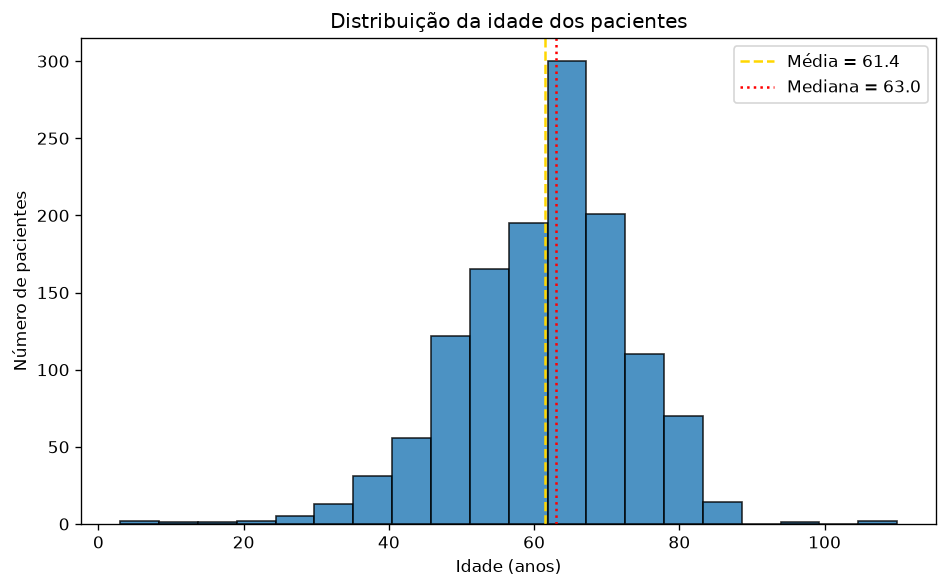

In [18]:
age_data = df_patient["age"].dropna()

fig,ax = plt.subplots(figsize=(8,5))

ax.hist(age_data,bins=20,edgecolor="black",alpha=0.8)

ax.axvline(age_data.mean(),color="gold",linestyle="--",linewidth=1.5,label=f"Média = {age_data.mean():.1f}")
ax.axvline(age_data.median(),color="red",linestyle=":",linewidth=1.5,label=f"Mediana = {age_data.median():.1f}")

ax.set_title("Distribuição da idade dos pacientes")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Número de pacientes")
ax.legend()

plt.tight_layout()
plt.show()

A idade média foi de 61.4 anos e a mediana de 63.0 anos. A maior concentração de pacientes ocorre entre aproximadamente 50 e 75 anos. A proximidade entre média e mediana indica pouca diferença entre as duas medidas de tendência central, embora existam alguns valores afastados da região de maior concentração.

## 11.2 Distribuição dos estágios de Retinopatia Diabética

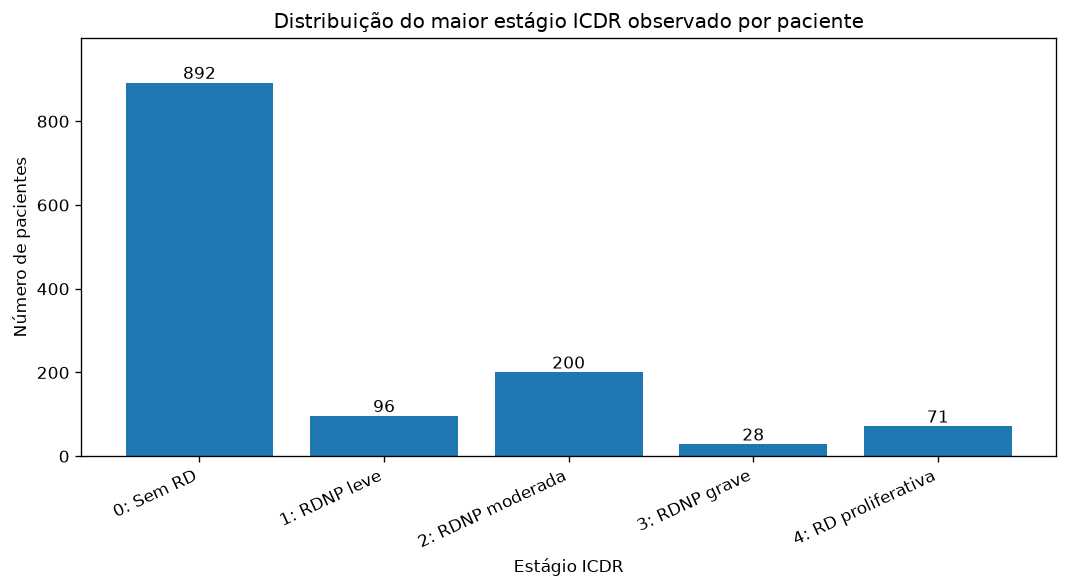

In [19]:
icdr_order = [ICDR_LABELS[i] for i in range(5)]
icdr_counts = df_patient["icdr_label"].value_counts().reindex(icdr_order,fill_value=0)

fig,ax = plt.subplots(figsize=(9,5))
ax.bar(icdr_counts.index,icdr_counts.values)
ax.set_title("Distribuição do maior estágio ICDR observado por paciente")
ax.set_xlabel("Estágio ICDR")
ax.set_ylabel("Número de pacientes")
ax.set_ylim(0,max(icdr_counts.max()*1.12,1))

plt.xticks(rotation=25,ha="right")

for i,value in enumerate(icdr_counts.values):
    ax.text(i,value,str(int(value)),ha="center",va="bottom")

plt.tight_layout()
plt.show()

Entre os 1.287 pacientes com classificação ICDR disponível, 892 (69.3%) foram classificados como sem RD. Entre os pacientes com algum estágio de Retinopatia Diabética, a RDNP moderada foi a categoria mais frequente, com 200 pacientes.

A distribuição entre os estágios é desigual, com poucos pacientes nos grupos de RDNP grave e RD proliferativa. Essa diferença no tamanho dos grupos será considerada nas comparações posteriores.

## 11.3 Duração da diabetes segundo o estágio ICDR

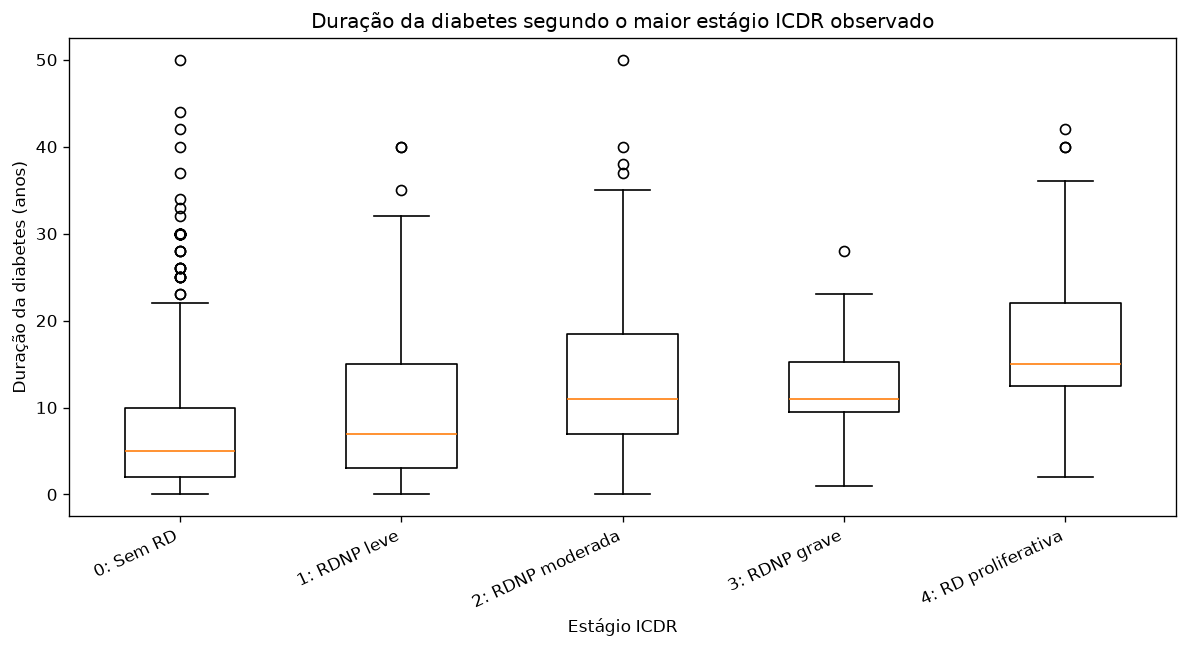

In [20]:
dm_stage_plot = df_patient[["icdr_patient","dm_time"]].dropna().copy()
dm_stage_plot["icdr_patient"] = dm_stage_plot["icdr_patient"].astype(int)

box_stages = [stage for stage in range(5) if (dm_stage_plot["icdr_patient"]==stage).any()]
box_data = [dm_stage_plot.loc[dm_stage_plot["icdr_patient"]==stage,"dm_time"].to_numpy() for stage in box_stages]
box_labels = [ICDR_LABELS[stage] for stage in box_stages]

fig,ax = plt.subplots(figsize=(10,5.5))
ax.boxplot(box_data,tick_labels=box_labels,showfliers=True)
ax.set_title("Duração da diabetes segundo o maior estágio ICDR observado")
ax.set_xlabel("Estágio ICDR")
ax.set_ylabel("Duração da diabetes (anos)")
plt.xticks(rotation=25,ha="right")
plt.tight_layout()
plt.show()

O gráfico mostra que a duração da diabetes tende a aumentar nos estágios mais avançados da Retinopatia Diabética. A mediana é de aproximadamente 5 anos no grupo sem RD, 7 anos na RDNP leve, 11 anos na RDNP moderada e grave e 15 anos na RD proliferativa.

Mesmo assim, há bastante sobreposição entre os grupos, principalmente entre RDNP moderada e grave. Isso mostra que pacientes em estágios diferentes podem ter tempos de diabetes semelhantes.

Também aparecem alguns valores mais afastados da distribuição, especialmente no grupo sem RD. Por enquanto, o gráfico mostra apenas uma tendência visual, vou explorar a comparação entre os grupos posteriormente com teste estatístico.

# 12. Análise de correlação

## Pergunta

Existe associação entre idade e duração do diabetes?

### Hipóteses

- H0: não há associação monotônica entre idade e duração da diabetes (ρs = 0).
- H1: há associação monotônica entre idade e duração da diabetes (ρs ≠ 0).

Nível de significância: α = 0.05.

A escolha entre Pearson e Spearman considera a distribuição das variáveis. O [teste de Shapiro-Wilk](https://www.uel.br/projetos/experimental/pages/arquivos/Shapiro.html) é usado para avaliar a hipótese de normalidade.

A correlação de Pearson é usada para avaliar relações lineares entre variáveis numéricas. Já a correlação de Spearman é baseada na ordenação dos valores e avalia relações monotônicas, sem exigir normalidade.

Neste notebook, Pearson é adotado quando ambas as variáveis não rejeitam a normalidade a 5% e, caso contrário, é adotado Spearman.

O coeficiente de correlação varia de -1 a 1. Valores positivos indicam associação na mesma direção, valores negativos indicam associação em direções opostas e valores próximos de zero indicam pouca associação. As categorias usadas para descrever sua intensidade servem apenas como referência e devem ser interpretadas junto ao contexto dos dados.

In [21]:
corr_data = df_patient[["age","dm_time"]].dropna().copy()

print("Pacientes com dados completos:", len(corr_data))

normality_rows = []

for col in ["age","dm_time"]:
    result = stats.shapiro(corr_data[col])
    normality_rows.append({
        "variavel":col,
        "W":result.statistic,
        "p_valor":result.pvalue,
        "assimetria":stats.skew(corr_data[col],bias=False),
        "normalidade_a_5pct":result.pvalue>=ALPHA,
    })

normality_corr = pd.DataFrame(normality_rows)

display(normality_corr.style.format({
    "W":"{:.6f}",
    "p_valor":"{:.2e}",
    "assimetria":"{:.6f}",
}))

Pacientes com dados completos: 1275


,variavel,W,p_valor,assimetria,normalidade_a_5pct
0,age,0.984345,1.70e-10,-0.420110,False
1,dm_time,0.873409,6.11e-31,1.328274,False


O teste de Shapiro-Wilk rejeitou a hipótese de normalidade para idade e duração da diabetes, pois ambos os valores de p foram menores que 0.05. A duração da diabetes também apresentou maior assimetria positiva.

Dessa forma, será utilizada a [correlação de Spearman](https://www.blog.psicometriaonline.com.br/o-que-e-correlacao-de-spearman) para avaliar a associação entre as duas variáveis.

In [22]:
corr_result = stats.spearmanr(corr_data["age"],corr_data["dm_time"])
corr_coef = float(corr_result.statistic)
corr_p = float(corr_result.pvalue)

print(f"Coeficiente de Spearman: {corr_coef:.4f}")
print(f"Valor-p: {corr_p:.6g}")

Coeficiente de Spearman: 0.2195
Valor-p: 2.24061e-15


A correlação de Spearman entre idade e duração da diabetes foi positiva e fraca, com ρ = 0.2195. O valor de p foi menor que 0.05, indicando evidência estatística de associação entre as duas variáveis.

Apesar da significância estatística, a magnitude da correlação é baixa. Isso indica que pacientes mais velhos tendem a apresentar maior duração da diabetes, mas essa relação é fraca. O resultado representa associação e não relação de causa e efeito.

## 12.1 Intervalo de confiança por bootstrap

Além do valor-p, é estimado um intervalo de confiança de 95% para o coeficiente por reamostragem em nível de paciente.

O [bootstrap](https://cursos.leg.ufpr.br/ce089/10_bootstrap.html) é uma técnica de reamostragem com reposição que permite estimar a variabilidade de uma estatística a partir dos próprios dados observados. Neste caso, o coeficiente de correlação é recalculado em várias amostras, e os resultados são usados para estimar seu intervalo de confiança.

Esse intervalo ajuda a mostrar a incerteza em torno da magnitude da associação observada.

In [23]:
def bootstrap_correlation(data,x_col,y_col,n_boot=2000,seed=42):
    rng = np.random.default_rng(seed)
    values = data[[x_col,y_col]].to_numpy()
    n = len(values)
    boot = []

    for _ in range(n_boot):
        sample = values[rng.integers(0,n,size=n)]
        x,y = sample[:,0],sample[:,1]

        if np.unique(x).size<2 or np.unique(y).size<2:
            continue

        value = stats.spearmanr(x,y).statistic

        if np.isfinite(value):
            boot.append(value)

    return tuple(float(v) for v in np.percentile(boot,[2.5,97.5]))

corr_ci_low,corr_ci_high = bootstrap_correlation(corr_data,"age","dm_time",n_boot=2000,seed=RANDOM_STATE)

print(f"IC95% bootstrap para Spearman: [{corr_ci_low:.4f}, {corr_ci_high:.4f}]")

IC95% bootstrap para Spearman: [0.1654, 0.2734]


O intervalo de confiança de 95% para a correlação de Spearman variou de 0.1654 a 0.2734. Como todo o intervalo está acima de zero, o resultado reforça a presença de uma associação positiva entre idade e duração da diabetes.

Mesmo considerando a incerteza da estimativa, os valores permanecem compatíveis com uma correlação de baixa magnitude.

## 12.2 Gráfico de dispersão

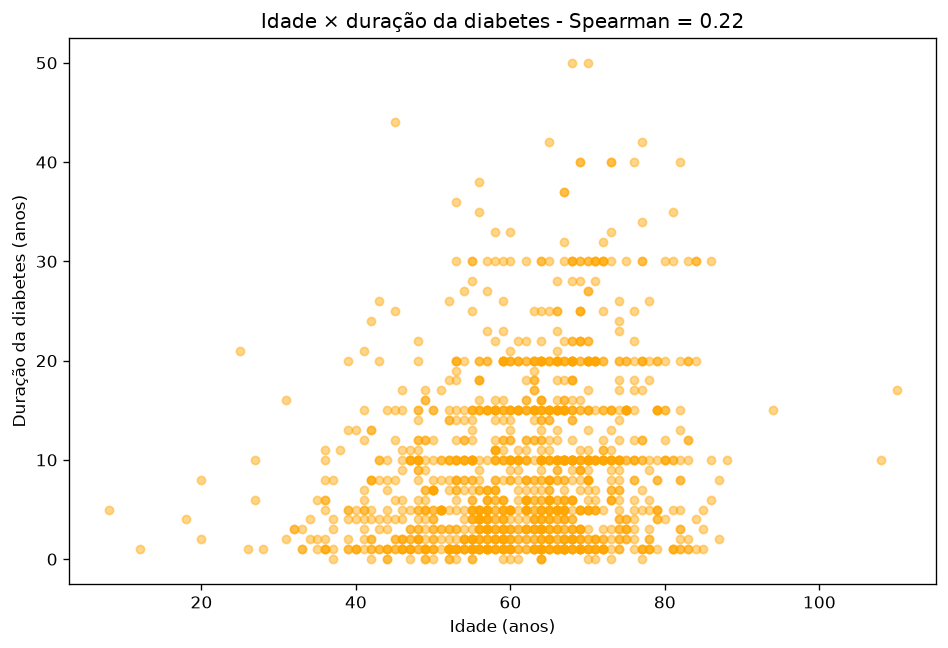

In [24]:
fig,ax = plt.subplots(figsize=(8,5.5))

ax.scatter(corr_data["age"],corr_data["dm_time"],color="orange",alpha=0.45,s=24)

ax.set_title(f"Idade × duração da diabetes - Spearman = {corr_coef:.2f}")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Duração da diabetes (anos)")

plt.tight_layout()
plt.show()

O gráfico mostra uma tendência de aumento da duração da diabetes conforme a idade aumenta, mas os pontos apresentam bastante dispersão. Pacientes de uma mesma faixa etária podem ter tempos de diabetes muito diferentes.

A correlação de Spearman foi de 0.22, indicando uma associação positiva de baixa magnitude. Assim, pacientes mais velhos tendem a apresentar maior duração da diabetes, mas a associação entre as duas variáveis é fraca.

A concentração de pontos em alguns valores horizontais ocorre porque a duração da diabetes é registrada principalmente em anos inteiros.

In [25]:
corr_conclusion = "rejeita-se H0" if corr_p<ALPHA else "não se rejeita H0"

print("Resultado da correlação")
print(f"n = {len(corr_data)} pacientes")
print(f"Coeficiente de Spearman = {corr_coef:.3f}")
print(f"IC95% bootstrap = [{corr_ci_low:.3f}; {corr_ci_high:.3f}]")
print(f"Valor-p = {corr_p:.3e}")
print(f"α = {ALPHA}")
print(f"Conclusão: {corr_conclusion}")

Resultado da correlação
n = 1275 pacientes
Coeficiente de Spearman = 0.220
IC95% bootstrap = [0.165; 0.273]
Valor-p = 2.241e-15
α = 0.05
Conclusão: rejeita-se H0


Como o valor de p foi menor que 0.05, rejeita-se H0. Há evidência estatística de uma associação monotônica entre idade e duração da diabetes.

A associação encontrada é positiva e de baixa magnitude com ρ = 0.220, com IC95% entre 0.165 e 0.273. Apesar da significância estatística, o coeficiente indica uma relação fraca entre as variáveis. Esse resultado não implica relação causal.

# 13. Comparação entre grupos

## Pergunta

A duração do diabetes dm_time difere entre os estágios de Retinopatia Diabética?

São comparados os níveis de icdr_patient entre pacientes com informações disponíveis sobre duração do diabetes e estágio ICDR.

### Hipóteses

- H0: não há diferença na duração do diabetes entre os estágios ICDR.
- H1: há diferença na duração do diabetes entre pelo menos dois estágios ICDR.

Nível de significância: α = 0.05.

Antes do teste global são apresentados o tamanho dos grupos, média, mediana e medidas de dispersão.

A ANOVA de uma via é usada quando os grupos não rejeitam a hipótese de normalidade a 5% e apresentam homogeneidade de variâncias. Quando essas condições não são atendidas, é usado o teste de [Kruskal-Wallis](https://pubmed.ncbi.nlm.nih.gov/9413454/).

O teste global é acompanhado por uma medida de tamanho de efeito. Caso H0 seja rejeitada, uma análise pós-hoc é realizada para verificar quais grupos apresentam diferenças entre si.

In [26]:
group_data = df_patient[["icdr_patient","dm_time"]].dropna().copy()
group_data["icdr_patient"] = group_data["icdr_patient"].astype(int)

group_summary = group_data.groupby("icdr_patient")["dm_time"].agg(
    n="count",media="mean",mediana="median",desvio_padrao="std",minimo="min",maximo="max"
)

group_summary["q1"] = group_data.groupby("icdr_patient")["dm_time"].quantile(0.25)
group_summary["q3"] = group_data.groupby("icdr_patient")["dm_time"].quantile(0.75)
group_summary["iiq"] = group_summary["q3"]-group_summary["q1"]
group_summary["estagio"] = group_summary.index.map(ICDR_LABELS)

assert len(group_summary)>=2,"A comparação entre grupos requer pelo menos dois estágios com dados."

display(group_summary[["estagio","n","media","mediana","desvio_padrao","minimo","maximo","iiq"]].round(2))

,estagio,n,media,mediana,desvio_padrao,minimo,maximo,iiq
icdr_patient,,,,,,,,
0,0: Sem RD,878,7.79,5.0,7.52,0.0,50.0,8.00
1,1: RDNP leve,95,9.85,7.0,9.27,0.0,40.0,12.00
2,2: RDNP moderada,199,13.31,11.0,8.57,0.0,50.0,11.50
3,3: RDNP grave,28,12.71,11.0,6.32,1.0,28.0,5.75
4,4: RD proliferativa,71,17.99,15.0,9.04,2.0,42.0,9.50


A duração da diabetes tende a ser maior nos estágios mais avançados, embora esse padrão não seja uniforme entre todos os grupos. A mediana foi de 5 anos entre pacientes sem RD, 7 anos na RDNP leve, 11 anos na RDNP moderada e grave e 15 anos na RD proliferativa/pós-laser.

Os tamanhos dos grupos são bastante diferentes, variando de 28 pacientes com RDNP grave a 878 sem RD. Por isso, a comparação inferencial deve considerar tanto as características das distribuições quanto essa diferença no número de pacientes entre os estágios.

## 13.1 Verificação dos pressupostos

A normalidade é avaliada separadamente em cada estágio pelo teste de Shapiro–Wilk. A homogeneidade das variâncias é avaliada pelo teste de Levene com centro na mediana, uma escolha menos sensível a desvios de normalidade.

Os resultados desses testes orientam a seleção entre ANOVA e Kruskal–Wallis; eles não são interpretados como achados clínicos.

In [27]:
group_arrays = {}
normality_rows = []

for stage in sorted(group_data["icdr_patient"].unique()):
    values = group_data.loc[group_data["icdr_patient"]==stage,"dm_time"].dropna().to_numpy()
    group_arrays[stage] = values
    if len(values)>=3:
        shapiro = stats.shapiro(values)
        normality_rows.append({"icdr":stage,"estagio":ICDR_LABELS.get(stage,str(stage)),"n":len(values),"W":shapiro.statistic,"p_valor":shapiro.pvalue,"normalidade_a_5pct":shapiro.pvalue>=ALPHA})

df_group_normality = pd.DataFrame(normality_rows)
display(df_group_normality)

levene_result = stats.levene(*group_arrays.values(),center="median")
print(f"Levene: estatística = {levene_result.statistic:.4f}, p = {levene_result.pvalue:.6g}")

,icdr,estagio,n,W,p_valor,normalidade_a_5pct
0,0,0: Sem RD,878,0.831226,1.917544e-29,False
1,1,1: RDNP leve,95,0.863582,7.115104e-08,False
2,2,2: RDNP moderada,199,0.930387,3.861299e-08,False
3,3,3: RDNP grave,28,0.964580,4.449139e-01,True
4,4,4: RD proliferativa,71,0.957404,1.688205e-02,False


Levene: estatística = 3.3674, p = 0.00944045


O teste de Shapiro-Wilk rejeitou a hipótese de normalidade em quatro dos cinco estágios ICDR. Apenas o grupo de RDNP grave apresentou valor de p maior que 0.05.

O teste de Levene também apresentou valor de p menor que 0.05, indicando diferença entre as variâncias dos grupos.

Como os pressupostos de normalidade e homogeneidade das variâncias não foram atendidos, será utilizado o teste de Kruskal-Wallis para comparar a duração da diabetes entre os estágios ICDR.

In [28]:
result = stats.kruskal(*group_arrays.values())

group_stat = float(result.statistic)
group_p = float(result.pvalue)

n_total = len(group_data)
k = len(group_arrays)
effect_size = max(0.0,float((group_stat-k+1)/(n_total-k)))

print("Teste: Kruskal-Wallis")
print(f"Estatística H: {group_stat:.4f}")
print(f"Valor-p: {group_p:.3e}")
print(f"Epsilon²: {effect_size:.4f}")

Teste: Kruskal-Wallis
Estatística H: 167.6991
Valor-p: 3.260e-35
Epsilon²: 0.1293


Como o valor de p foi muito menor que 0.05, rejeita-se H0. Isso indica que a duração da diabetes não se distribui da mesma forma em todos os estágios ICDR.

O teste de Kruskal-Wallis mostra que existe diferença entre pelo menos dois grupos, mas não informa quais estágios diferem entre si. Por isso, a próxima etapa é realizar uma análise pós-hoc.

## 13.2 Análise pós-hoc

Como o teste de Kruskal-Wallis rejeitou H0, são realizadas comparações entre os pares de estágios para identificar onde estão as diferenças.

É usado o teste de Mann-Whitney para cada par de grupos, com correção de Holm nos valores de p para controlar o erro causado pelas múltiplas comparações.

In [29]:
pair_rows = []

for stage_a,stage_b in combinations(sorted(group_arrays),2):
    result = stats.mannwhitneyu(group_arrays[stage_a],group_arrays[stage_b],alternative="two-sided")
    pair_rows.append({
        "grupo_1":ICDR_LABELS[stage_a],
        "grupo_2":ICDR_LABELS[stage_b],
        "U":result.statistic,
        "p_bruto":result.pvalue,
    })

posthoc_df = pd.DataFrame(pair_rows)

reject,p_holm,_,_ = multipletests(posthoc_df["p_bruto"],alpha=ALPHA,method="holm")
posthoc_df["p_holm"] = p_holm
posthoc_df["rejeita_h0"] = reject

display(posthoc_df)

,grupo_1,grupo_2,U,p_bruto,p_holm,rejeita_h0
0,0: Sem RD,1: RDNP leve,37111.5,7.615789e-02,1.523158e-01,False
1,0: Sem RD,2: RDNP moderada,49518.0,9.060197e-22,9.060197e-21,True
2,0: Sem RD,3: RDNP grave,6569.0,2.466040e-05,1.726228e-04,True
3,0: Sem RD,4: RD proliferativa,10906.0,5.212461e-20,4.691215e-19,True
4,1: RDNP leve,2: RDNP moderada,6751.0,7.147123e-05,3.573562e-04,True
5,1: RDNP leve,3: RDNP grave,918.0,1.277091e-02,3.831273e-02,True
6,1: RDNP leve,4: RD proliferativa,1613.0,8.503436e-09,6.802749e-08,True
7,2: RDNP moderada,3: RDNP grave,2755.0,9.250138e-01,9.250138e-01,False
8,2: RDNP moderada,4: RD proliferativa,4793.0,5.465831e-05,3.279498e-04,True
9,3: RDNP grave,4: RD proliferativa,640.0,5.613832e-03,2.245533e-02,True


Após a correção de Holm, foram encontradas diferenças entre a maioria dos pares de estágios.

Não houve diferença estatisticamente detectável entre os grupos sem RD e RDNP leve (p ajustado = 0.152), nem entre RDNP moderada e RDNP grave (p ajustado = 0.925). Nos demais pares, os valores de p ajustados ficaram abaixo de 0.05.

Considerando também as medianas observadas anteriormente, os resultados mostram que as diferenças na duração da diabetes aparecem principalmente entre estágios mais afastados de gravidade. Ainda assim, nem todos os estágios consecutivos apresentam diferenças estatisticamente detectáveis.

# 14. Variabilidade das variáveis

A atividade solicita identificar quais variáveis apresentam maior variabilidade. Como idade e tempos estão na mesma unidade, o desvio-padrão pode ser lido diretamente, o coeficiente de variação (CV) é mantido como complemento para comparar dispersão relativa em relação à média.

insulin_time continua restrita ao subgrupo em insulinoterapia, portanto sua variabilidade descreve esse grupo sem ser a amostra toda.

In [30]:
variability_table = df_numeric_summary[["n","media","desvio_padrao","iiq","cv_pct"]].sort_values("cv_pct",ascending=False)
display(variability_table.round(2))

,n,media,desvio_padrao,iiq,cv_pct
variavel,,,,,
insulin_time,252,7.76,7.98,8.0,102.83
dm_time,1275,9.48,8.40,12.0,88.57
age,1291,61.45,11.64,14.0,18.94


Considerando a dispersão relativa, insulin_time apresentou a maior variabilidade, com CV de 102.83%, seguida por dm_time, com 88.57%. A idade apresentou menor variabilidade relativa, com CV de 18.94%.

Em valores absolutos, a idade apresentou o maior desvio-padrão de 11.64 anos e o maior IIQ de 14 anos. Já o resultado de insulin_time deve ser interpretado separadamente, pois considera apenas os 252 pacientes em insulinoterapia com tempo de uso informado.

Assim, a idade apresenta maior dispersão absoluta, enquanto o tempo de insulinoterapia apresenta maior dispersão em relação à sua própria média.

# 15. Interpretação integrada dos resultados

A análise em nível de paciente permitiu reunir os resultados descritivos, gráficos e estatísticos obtidos ao longo do notebook. Nesta seção, esses resultados são interpretados em conjunto, considerando também as características e limitações dos dados.

## 15.1 Características da população analisada

A análise incluiu 1.291 pacientes. A idade média foi de 61.45 anos, com mediana de 63 anos e desvio-padrão de 11.64 anos. A amostra foi composta por 65.07% de pacientes do sexo feminino e 34.93% do sexo masculino.

O histograma de idade mostrou maior concentração de pacientes aproximadamente entre 50 e 75 anos. A proximidade entre média e mediana também indica pouca diferença entre essas duas medidas de tendência central, embora existam algumas idades mais afastadas da região de maior concentração.

A classificação ICDR estava disponível para 1.287 pacientes. O gráfico de barras mostrou que 892 pacientes, correspondentes a 69.3% dos casos com classificação disponível, não apresentavam Retinopatia Diabética. Entre os pacientes com RD, o estágio mais frequente foi a RDNP moderada, com 200 pacientes.

As frequências das características clínicas também mostraram que 70.80% dos pacientes apresentavam hipertensão sistêmica, 83.89% realizavam tratamento oral e 20.60% faziam uso de insulina. O edema macular esteve presente em 12.08% da amostra.

## 15.2 Variabilidade das variáveis numéricas

A idade apresentou a maior dispersão absoluta, com desvio-padrão de 11.64 anos e intervalo interquartil de 14 anos.

Quando a dispersão é considerada em relação à própria média, o tempo de insulinoterapia apresentou o maior coeficiente de variação, com 102.83%, seguido pela duração da diabetes, com 88.57%. A idade apresentou menor dispersão relativa, com coeficiente de variação de 18.94%.

O resultado referente ao tempo de insulinoterapia deve ser interpretado separadamente, pois considera somente os 252 pacientes em uso de insulina que possuíam essa informação disponível.

Assim, a idade apresenta maior dispersão em valores absolutos, enquanto o tempo de insulinoterapia apresenta maior dispersão quando comparado à sua própria média.

## 15.3 Associação entre idade e duração da diabetes

O gráfico de dispersão entre idade e duração da diabetes mostrou uma tendência de aumento da duração da doença conforme a idade aumenta. Entretanto, os pontos apresentaram bastante dispersão, indicando que pacientes com idades semelhantes podem ter tempos de diabetes bastante diferentes.

Essa impressão visual foi destacada pela correlação de Spearman. O coeficiente encontrado foi de 0.220, com intervalo de confiança de 95% entre 0.165 e 0.273.

O valor de p foi menor que 0.05, levando à rejeição de H0. Há, portanto, evidência de associação entre idade e duração da diabetes. A associação é positiva, mas de baixa magnitude.

Dessa forma, pacientes mais velhos tendem a apresentar maior duração da diabetes, porém a idade apresenta apenas uma relação fraca com o tempo da doença. Esse resultado não indica uma relação de causa e efeito.

## 15.4 Duração da diabetes e estágios da Retinopatia Diabética

O boxplot da duração da diabetes segundo os estágios ICDR mostrou uma tendência de aumento das medianas nos estágios mais avançados da doença.

A mediana foi de aproximadamente 5 anos entre pacientes sem RD, 7 anos na RDNP leve, 11 anos na RDNP moderada e grave e 15 anos na RD proliferativa/pós-laser.

Apesar dessa tendência, o gráfico também mostrou sobreposição entre as distribuições. Pacientes pertencentes a estágios diferentes podem apresentar durações da diabetes semelhantes, especialmente nos grupos de RDNP moderada e grave.

O teste de Kruskal-Wallis apresentou H = 167.699 e valor de p muito menor que 0.05. Dessa forma, H0 foi rejeitada, indicando que a distribuição da duração da diabetes não é igual em todos os estágios ICDR.

A análise pós-hoc permitiu identificar onde essas diferenças ocorreram. Após a correção de Holm, não foi encontrada diferença estatisticamente detectável entre pacientes sem RD e pacientes com RDNP leve. Também não foi encontrada diferença entre RDNP moderada e RDNP grave.

Nos demais pares de estágios foram observadas diferenças estatisticamente detectáveis.

Esses resultados são compatíveis com o padrão observado no gráfico boxplot: a duração da diabetes tende a ser maior nos estágios mais avançados, mas não existe uma separação clara entre todos os níveis consecutivos da classificação ICDR.

## 15.5 Relação entre os resultados gráficos e estatísticos

Os gráficos e os testes estatísticos apresentaram resultados consistentes entre si.

O gráfico de dispersão mostrou uma tendência positiva entre idade e duração da diabetes, enquanto a correlação de Spearman confirmou que essa associação existe, embora seja fraca.

Da mesma forma, o boxplot mostrou aumento da duração da diabetes nos estágios mais avançados da RD. O teste de Kruskal-Wallis confirmou que existem diferenças entre os grupos, enquanto a análise pós-hoc mostrou que essas diferenças não aparecem entre todos os pares de estágios.

O gráfico de barras da classificação ICDR também mostrou uma distribuição bastante desigual entre os grupos. A maior parte dos pacientes não apresentava RD, enquanto alguns estágios possuíam poucos pacientes. A RDNP grave, por exemplo, apresentou apenas 28 pacientes, enquanto o grupo sem RD concentrou 892 pacientes na caracterização geral.

Essa diferença no tamanho dos grupos deve ser considerada ao interpretar as comparações.

## 15.6 Evidência estatística e interpretação clínica

As duas análises estatísticas principais rejeitaram suas respectivas hipóteses nulas ao nível de 5%.

Foi encontrada associação entre idade e duração da diabetes e também diferença na duração da diabetes entre os estágios ICDR.

Entretanto, um valor de p baixo não determina sozinho a importância clínica de um resultado.

Na análise de correlação, apesar da evidência estatística, o coeficiente de 0.220 indica uma associação fraca. Na comparação entre os estágios, embora tenham sido encontradas diferenças entre vários grupos, o boxplot mostra sobreposição entre as distribuições.

Por isso, os valores de p devem ser interpretados juntamente com os coeficientes, intervalos de confiança, medidas descritivas, gráficos e características da amostra.

## 15.7 Limitações

- O arquivo original possui quatro imagens para cada paciente. Para evitar que imagens do mesmo indivíduo fossem consideradas observações independentes, os dados clínicos e demográficos foram organizados em uma única observação por paciente antes das análises;

- O estágio ICDR de cada paciente foi definido pelo maior estágio encontrado entre suas imagens disponíveis. Essa é uma decisão adotada nesta análise e não corresponde a um rótulo de paciente fornecido diretamente pelo conjunto de dados;

- Os valores ausentes não foram preenchidos de forma geral. Cada análise considerou os pacientes que possuíam as informações necessárias para as variáveis envolvidas. O tempo de insulinoterapia foi analisado apenas entre pacientes em uso de insulina com essa informação disponível;

- Os grupos ICDR também apresentam tamanhos bastante diferentes, especialmente entre o grupo sem RD e os estágios menos frequentes. Essa característica deve ser considerada na interpretação das comparações;

- Algumas informações clínicas, tratamentos e comorbidades do mBRSET são autorreferidos, estando sujeitos a erro de informação. Além disso, os dados foram obtidos em um contexto específico de coleta no Brasil, o que também deve ser considerado ao avaliar a possibilidade de generalização dos resultados;

- Por fim, os resultados descrevem os pacientes presentes no mBRSET e não devem ser generalizados diretamente para toda a população com diabetes ou Retinopatia Diabética.

# 16. Conclusão

A análise foi realizada com 1.291 pacientes do mBRSET. Como o conjunto original possui quatro imagens por paciente, os dados foram organizados em nível de indivíduo antes das análises estatísticas, evitando que registros do mesmo paciente fossem considerados observações independentes.

A população apresentou idade média de 61.45 anos e foi composta majoritariamente por mulheres. A maior parte dos pacientes com classificação ICDR disponível não apresentava Retinopatia Diabética, enquanto a RDNP moderada foi o estágio mais frequente entre aqueles com RD.

Foi encontrada uma associação positiva e de baixa magnitude entre idade e duração da diabetes. A correlação de Spearman foi de 0.220, com IC95% entre 0.165 e 0.273 e valor de p menor que 0.05. Apesar da evidência estatística, o gráfico de dispersão mostrou ampla variação da duração da diabetes entre pacientes de idades semelhantes.

A duração da diabetes também apresentou diferenças entre os estágios ICDR. O boxplot mostrou aumento das medianas nos estágios mais avançados, e o teste de Kruskal-Wallis confirmou diferenças entre os grupos, com H = 167.699 e valor de p menor que 0.05. Na análise pós-hoc, não foram encontradas diferenças entre os grupos sem RD e RDNP leve, nem entre RDNP moderada e RDNP grave. Os demais pares apresentaram diferenças estatisticamente detectáveis.

Os resultados indicam, portanto, uma tendência de maior duração da diabetes nos estágios mais avançados da Retinopatia Diabética, embora exista sobreposição entre as distribuições e nem todos os estágios consecutivos apresentem diferenças detectáveis.

Essas informações devem ser interpretadas considerando as características da amostra e as decisões adotadas na análise. O estágio ICDR de cada paciente foi definido pelo maior estágio observado entre suas imagens, os valores ausentes foram tratados conforme as variáveis envolvidas em cada procedimento e não houve controle de possíveis fatores de confusão.

Dessa forma, os resultados descrevem os pacientes presentes no mBRSET e não permitem estabelecer relações causais nem devem ser generalizados diretamente para toda a população com diabetes ou Retinopatia Diabética.

# Referências

1. Wu, C., Restrepo, D., Nakayama, L.F. et al. A portable retina fundus photos dataset for clinical, demographic, and diabetic retinopathy prediction. Sci Data 12, 323 (2025). https://doi.org/10.1038/s41597-025-04627-3

2. Nakayama, L. F., Zago Ribeiro, L., Restrepo, D., Santos Barboza, N., Dias Fiterman, R., Vieira Sousa, M. l., Pereira, A. D. A., Regatieri, C., Malerbi, F. K., and Andrade, R. (2024) 'mBRSET, a Mobile Brazilian Retinal Dataset' (version 1.0), PhysioNet. RRID:SCR_007345. Available at: https://doi.org/10.13026/qxpd-1y65

3. Wilkinson CP, Ferris FL 3rd, Klein RE, Lee PP, Agardh CD, Davis M, Dills D, Kampik A, Pararajasegaram R, Verdaguer JT; Global Diabetic Retinopathy Project Group. Proposed international clinical diabetic retinopathy and diabetic macular edema disease severity scales. Ophthalmology. 2003 Sep;110(9):1677-82. doi: 10.1016/S0161-6420(03)00475-5. PMID: 13129861.

4. Sapra, Varun & Sapra, Luxmi & Bhardwaj, Akashdeep & Almogren, Ahmad & Bharany, Salil & Rehman, Ateeq & Ouahada, Khmaies. (2024). Diabetic Retinopathy Detection Using Deep Learning with Optimized Feature Selection. Traitement du Signal. 41. 781-790. 10.18280/ts.410219.

5. S. S. SHAPIRO, M. B. WILK, An analysis of variance test for normality (complete samples), Biometrika, Volume 52, Issue 3-4, December 1965, Pages 591–611, https://doi.org/10.1093/biomet/52.3-4.591

6. Spearman, C. (1904) The Proof and Measurement of Association between Two Things. The American Journal of Psychology, 15, 72-101.
https://doi.org/10.2307/1412159

7.  Pearson, K. (1895) Notes on Regression and Inheritance in the Case of Two Parents Proceedings of the Royal Society of London, 58, 240-242. https://doi.org/10.1098/rspl.1895.0041

8.  B. Efron. "Bootstrap Methods: Another Look at the Jackknife." Ann. Statist. 7 (1) 1 - 26, January, 1979. https://doi.org/10.1214/aos/1176344552

9. Pollard, T., Moody, B.E., Lehman, L., Gow, B., Fernandes, C., Xie, C., Johnson, A., Mark, R.G. and Heldt, T., 2026. PhysioNet as a global platform for biomedical research. Nature Health. Available at: https://doi.org/10.1038/s44360-026-00096-z. Available from: https://rdcu.be/faatM

10. Kruskal, W. H., & Wallis, W. A. (1952). Use of Ranks in One-Criterion Variance Analysis. Journal of the American Statistical Association, 47(260), 583–621. https://doi.org/10.1080/01621459.1952.10483441

11.  H. B. Mann. D. R. Whitney. "On a Test of Whether one of Two Random Variables is Stochastically Larger than the Other." Ann. Math. Statist. 18 (1) 50 - 60, March, 1947. https://doi.org/10.1214/aoms/1177730491

12. Holm, S. (1979) “A Simple Sequentially Rejective Multiple Test Procedure,” Scandinavian Journal of Statistics. doi: 10.2307/4615733.

13. Paranhos, R., Figueiredo Filho, D. B., Rocha, E. C. da, Silva Júnior, J. A. da, Neves, J. A. B., & Santos, M. L. W. D. (2014). Desvendando os Mistérios do Coeficiente de Correlação de Pearson: o Retorno. Leviathan (São Paulo), 8, 66-95. https://doi.org/10.11606/issn.2237-4485.lev.2014.132346

14. **Mayer, F. P.** Métodos de reamostragem: Bootstrap. Material da disciplina de Estatística Computacional, Universidade Federal do Paraná. Dispónivel em: https://cursos.leg.ufpr.br/ce089/10_bootstrap.html#1_Introdu%C3%A7%C3%A3o

15. Brown, M. B., & Forsythe, A. B. (1974). Robust Tests for the Equality of Variances. Journal of the American Statistical Association, 69(346), 364–367. https://doi.org/10.1080/01621459.1974.10482955


- PhysioNet: https://physionet.org/content/mbrset/1.0/
- Repositório dos autores: https://github.com/luisnakayama/mBRSET